In [3]:
# Stage 1 — Dataset Loading

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/muhammadaliparacha/lab-04/Iris.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())

(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


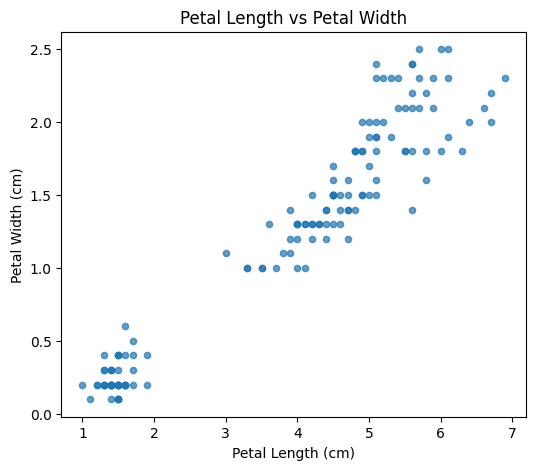

In [4]:
# Stage 2 — Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    s=20,
    alpha=0.7
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")

plt.show()

In [5]:
# Stage 3 — Preprocessing

feature_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[feature_cols].values

print(X.shape)

(150, 4)


In [6]:
# Stage 4 — Training

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

print("K-Means training completed.")

K-Means training completed.


In [7]:
# Stage 5 — Testing

df["Cluster"] = kmeans.predict(X)

print(df["Cluster"].value_counts())

Cluster
0    62
1    50
2    38
Name: count, dtype: int64


In [8]:
# Stage 6 — Validation

comparison = pd.crosstab(
    df["Cluster"],
    df["Species"]
)

print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               48              14
1                 50                0               0
2                  0                2              36
